<h1 style = 'color: red'>Space X Falcon 9 First Stage Landing Prediction</h1>

<h3 style = 'color: yellow'>Assignment: Exploring and Preparing Data</h3>
<h3 style = 'color: yellow'>Exploratory Data Analysis</h3>
<h3 style = 'color: yellow'>Preparing Data Feature Engineering</h3>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<h3 style = 'color: yellow'>Explorartory Data Analysis</h3>

In [2]:
import requests
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
df = pd.read_csv(url)
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


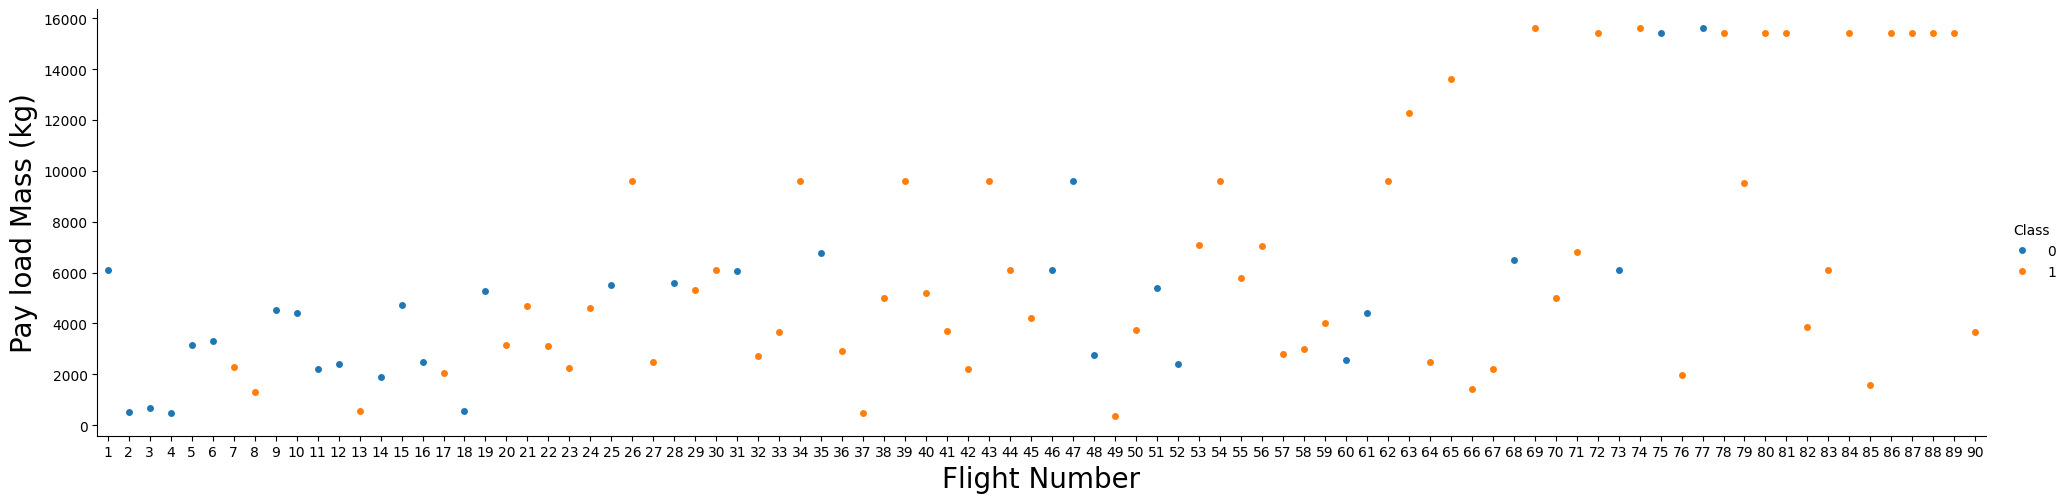

In [4]:
sns.catplot(y = 'PayloadMass', x = 'FlightNumber', hue = 'Class', data = df, aspect = 4)
plt.xlabel('Flight Number', fontsize = 20)
plt.ylabel('Pay load Mass (kg)', fontsize = 20)
plt.show()

catplot() stands for categorical plot, which is a figure-level function in Seaborn used to visualize categorical data

<h3 style = 'color: yellow'>Task1: visualize the relationship between flight number and launch site</h3>

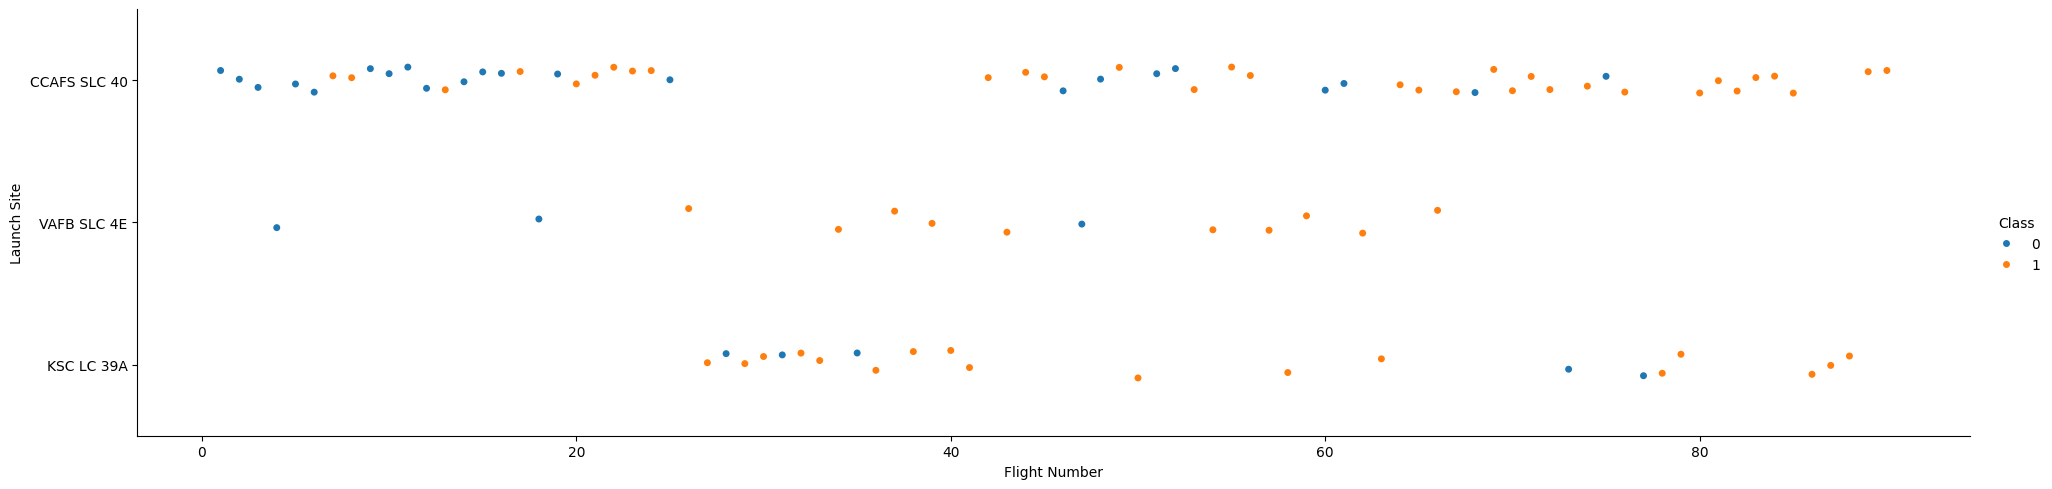

In [6]:
sns.catplot(y = 'LaunchSite', x = 'FlightNumber', hue = 'Class', data = df, aspect = 4)
plt.xlabel('Flight Number')
plt.ylabel('Launch Site')
plt.show()

<h3 style = 'color: yellow'>Task2: visualize the relationship between Payload Mass and Launch Site</h3>

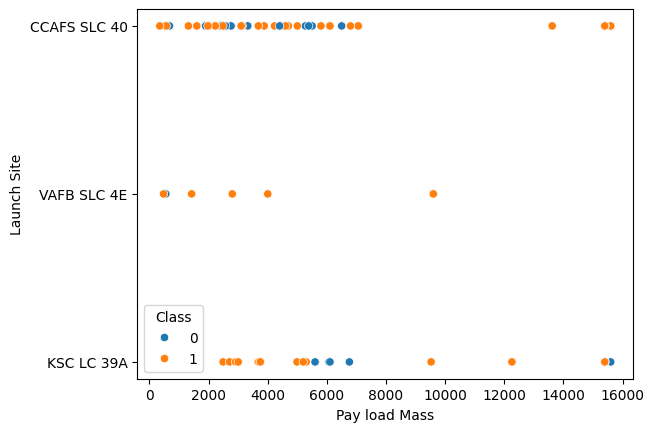

In [9]:
sns.scatterplot(x = 'PayloadMass', y = 'LaunchSite', data = df, hue = 'Class')
plt.xlabel('Pay load Mass')
plt.ylabel('Launch Site')
plt.show()

VAFB-SLC launch site, there are no rockets launched for heavy pay load mass (greater than 10,000)

<h3 style = 'color: yellow'>Task3: visualize the relationship between success rate of each orbit type</h3>

In [12]:
orbit_df = df.groupby('Orbit')['Class'].mean().reset_index()
orbit_df

,Orbit,Class
0,ES-L1,1.000000
1,GEO,1.000000
2,GTO,0.518519
3,HEO,1.000000
4,ISS,0.619048
5,LEO,0.714286
6,MEO,0.666667
7,PO,0.666667
8,SO,0.000000
9,SSO,1.000000


groupby() function can group the orbit type and generate a new dataframe.

And [''].mean() create a new column and get the mean value

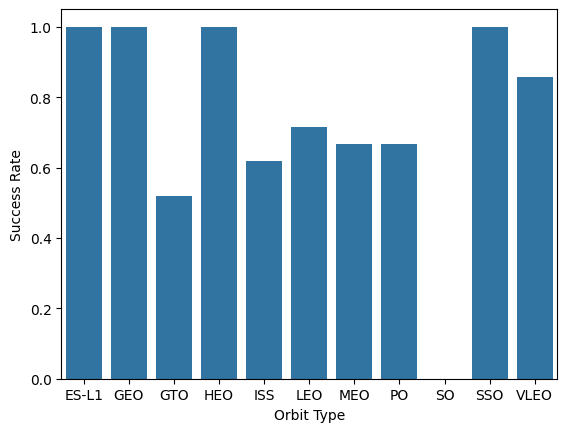

In [13]:
sns.barplot(x = 'Orbit', y = 'Class', data = orbit_df)
plt.xlabel('Orbit Type')
plt.ylabel('Success Rate')
plt.show()

<h3 style = 'color: yellow'>Task4: visualize the relationship between flight number and orbit type</h3>

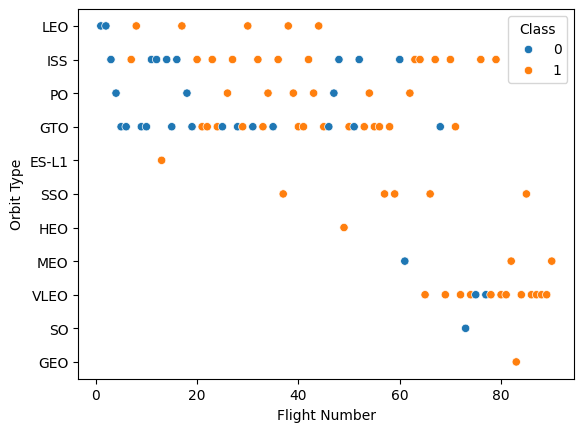

In [14]:
sns.scatterplot(x = 'FlightNumber', y = 'Orbit', hue = 'Class', data = df)
plt.xlabel('Flight Number')
plt.ylabel('Orbit Type')
plt.show()

<h3 style = 'color: yellow'>Task5: visualize the relationship bwtween payload mass and orbit type</h3>

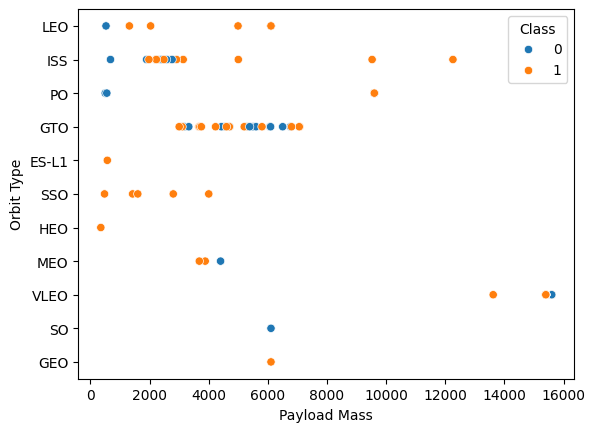

In [15]:
sns.scatterplot(x = 'PayloadMass', y = 'Orbit', hue = 'Class', data = df)
plt.xlabel('Payload Mass')
plt.ylabel('Orbit Type')
plt.show()

<h3 style = 'color: yellow'>Task6: visualize the launch success yearly trend</h3>

In [16]:
# a function extracts year
year = []
def extract_year():
    for i in df['Date']:
        year.append(i.split('-')[0])
    return year
extract_year()
df['Date'] = year
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [18]:
year_df = df.groupby('Date')['Class'].mean().reset_index()
year_df

,Date,Class
0,2010,0.000000
1,2012,0.000000
2,2013,0.000000
3,2014,0.333333
4,2015,0.333333
5,2016,0.625000
6,2017,0.833333
7,2018,0.611111
8,2019,0.900000
9,2020,0.842105


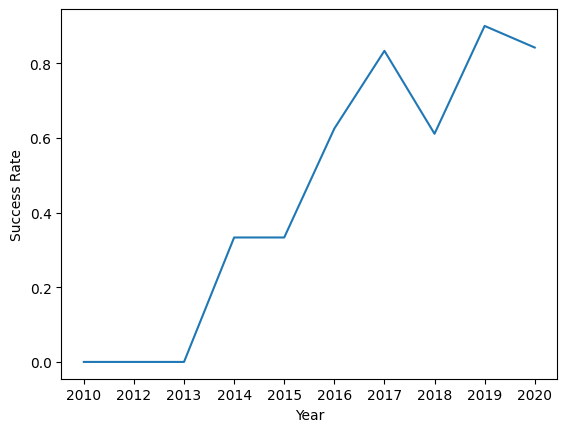

In [19]:
sns.lineplot(x = 'Date', y = 'Class', data = year_df)
plt.xlabel('Year')
plt.ylabel('Success Rate')
plt.show()

<h3 style = 'color: yellow'>Features Engineering</h3>

In [20]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 
               'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 
               'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


<h3 style = 'color: yellow'>Task7: create dummy variables to categorical columns</h3>

In [21]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   FlightNumber  90 non-null     int64  
 1   PayloadMass   90 non-null     float64
 2   Orbit         90 non-null     object 
 3   LaunchSite    90 non-null     object 
 4   Flights       90 non-null     int64  
 5   GridFins      90 non-null     bool   
 6   Reused        90 non-null     bool   
 7   Legs          90 non-null     bool   
 8   LandingPad    64 non-null     object 
 9   Block         90 non-null     float64
 10  ReusedCount   90 non-null     int64  
 11  Serial        90 non-null     object 
dtypes: bool(3), float64(2), int64(3), object(4)
memory usage: 6.7+ KB


from above table, we can tell that <code>Orbit</code>, 
<code>LaunchSite</code>, 
<code>LandingPad</code>,
<code>Serial</code> are object type and we shall OneHotEncoder them by using <code>get_dummies</code>

In [23]:
features_one_hot = pd.get_dummies(features, columns = ['Orbit', 'LaunchSite', 'LandingPad', 'Serial'])
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


<h3 style = 'color: yellow'>Task8: cast all numeric columns to <code>float64</code></h3>

In [24]:
features_one_hot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 80 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   FlightNumber                         90 non-null     int64  
 1   PayloadMass                          90 non-null     float64
 2   Flights                              90 non-null     int64  
 3   GridFins                             90 non-null     bool   
 4   Reused                               90 non-null     bool   
 5   Legs                                 90 non-null     bool   
 6   Block                                90 non-null     float64
 7   ReusedCount                          90 non-null     int64  
 8   Orbit_ES-L1                          90 non-null     bool   
 9   Orbit_GEO                            90 non-null     bool   
 10  Orbit_GTO                            90 non-null     bool   
 11  Orbit_HEO                         

In [28]:
features_one_hot[features_one_hot.select_dtypes(include = ['number', 'bool']).columns] = features_one_hot.select_dtypes(include = ['number', 'bool']).astype('float64')

In [29]:
features_one_hot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 80 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   FlightNumber                         90 non-null     float64
 1   PayloadMass                          90 non-null     float64
 2   Flights                              90 non-null     float64
 3   GridFins                             90 non-null     float64
 4   Reused                               90 non-null     float64
 5   Legs                                 90 non-null     float64
 6   Block                                90 non-null     float64
 7   ReusedCount                          90 non-null     float64
 8   Orbit_ES-L1                          90 non-null     float64
 9   Orbit_GEO                            90 non-null     float64
 10  Orbit_GTO                            90 non-null     float64
 11  Orbit_HEO                         

In [30]:
features_one_hot.to_csv('dataset_part_3.csv', index = False)